# Análisis Faraday Rotation
**Objetivo:** Medir la constante de Verdet de una mezcla de cuarzo y vidrio

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [13]:
# Datos
I = np.array([0.13, 0.29, 0.45, 0.61, 0.76])       # Corriente (A)
VPP = 0.108                                          # Voltaje pico a pico (V)
VAC = np.array([0.49, 1.09, 1.64, 2.25, 2.79]) * 1e-5  # Voltaje AC RMS (V)
n = 214.4                                           # Número de vueltas del solenoide
d = 0.114                                          # Longitud de la muestra (m)

# Constante de permeabilidad magnética en el vacío
mu_0 = 4 * np.pi * 1e-7  # H/m

def verdet_function(I, V):
    """
    Función para calcular la constante de Verdet
    V = (√2 * V_ac_rms) / (2 * μ₀ * I * n * d * V_pp)
    
    Parámetros:
    I: corriente (A)
    V: constante de Verdet (rad/(T·m))
    
    Retorna:
    V_ac_rms calculado
    """
    # Campo magnético B = μ₀ * I * n / d  (aproximación para solenoide largo)
    
    # De la ecuación de Faraday: θ = V * B * L
    # Donde θ se relaciona con VAC a través de la detección síncrona
    # VAC = (√2 * V_ac_rms) / (2 * μ₀ * I * n * d * V_pp) * V
    V_ac_calculated = 2 * V * mu_0 * I * n * d * VPP / np.sqrt(2)
    
    return V_ac_calculated

print("Datos experimentales:")
print(f"Corriente I (A): {I}")
print(f"VAC RMS (V): {VAC}")
print(f"Voltaje pico a pico: {VPP} V")
print(f"Número de vueltas: {n}")
print(f"Longitud de la muestra: {d} m")

Datos experimentales:
Corriente I (A): [0.13 0.29 0.45 0.61 0.76]
VAC RMS (V): [4.90e-06 1.09e-05 1.64e-05 2.25e-05 2.79e-05]
Voltaje pico a pico: 0.108 V
Número de vueltas: 214.4
Longitud de la muestra: 0.114 m


In [15]:
# Ajuste de curva para obtener la constante de Verdet
def fit_function(I, V):
    """Función para el ajuste de curva"""
    return verdet_function(I, V)

# Realizar el ajuste de curva
try:
    # Estimación inicial para la constante de Verdet
    initial_guess = [1e-6]  # rad/(T·m)
    
    # Ajuste de curva
    popt, pcov = curve_fit(fit_function, I, VAC, p0=initial_guess)
    
    # Extraer la constante de Verdet ajustada
    V_fitted = popt[0]
    V_error = np.sqrt(np.diag(pcov))[0]
    
    print(f"\nResultados del ajuste:")
    print(f"Constante de Verdet: {V_fitted:.2e} ± {V_error:.2e} rad/(T·m)")
    
    # Calcular valores teóricos para la curva ajustada
    I_theory = np.linspace(I.min(), I.max(), 100)
    VAC_theory = fit_function(I_theory, V_fitted)
    
    # Calcular R²
    VAC_fit = fit_function(I, V_fitted)
    ss_res = np.sum((VAC - VAC_fit) ** 2)
    ss_tot = np.sum((VAC - np.mean(VAC)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    print(f"Coeficiente de determinación R²: {r_squared:.4f}")
    
except Exception as e:
    print(f"Error en el ajuste: {e}")
    V_fitted = 1e-6  # Valor por defecto
    I_theory = np.linspace(I.min(), I.max(), 100)
    VAC_theory = fit_function(I_theory, V_fitted)


Resultados del ajuste:
Constante de Verdet: 7.84e+00 ± 2.98e-02 rad/(T·m)
Coeficiente de determinación R²: 0.9997


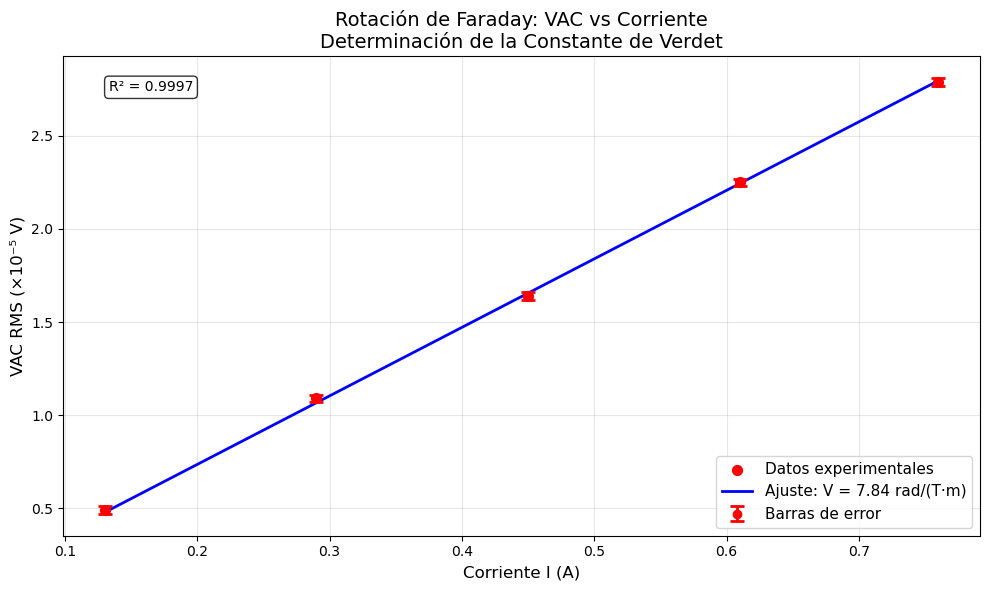


Información adicional:
Campo magnético máximo: 1.80 mT
Campo magnético mínimo: 0.31 mT
Rango de VAC: 0.49 - 2.79 ×10⁻⁵ V


In [11]:
# Crear el gráfico
plt.figure(figsize=(10, 6))

# Puntos experimentales
plt.scatter(I, VAC * 1e5, color='red', s=50, zorder=5, label='Datos experimentales')

VAC_err = 0.02 * 1e-5  # Error de VAC en V

# Puntos experimentales con barras de error
plt.errorbar(I, VAC * 1e5, yerr=VAC_err * 1e5, 
             fmt='ro', markersize=6, capsize=5, capthick=2, 
             elinewidth=2, zorder=5, label='Barras de error')

# Curva ajustada
plt.plot(I_theory, VAC_theory * 1e5, 'b-', linewidth=2, label=f'Ajuste: V = {V_fitted:.2f} rad/(T·m)')

# Configuración del gráfico
plt.xlabel('Corriente I (A)', fontsize=12)
plt.ylabel('VAC RMS (×10⁻⁵ V)', fontsize=12)
plt.title('Rotación de Faraday: VAC vs Corriente\nDeterminación de la Constante de Verdet', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Añadir información estadística al gráfico
if 'r_squared' in locals():
    plt.text(0.05, 0.95, f'R² = {r_squared:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             verticalalignment='top', fontsize=10)

plt.tight_layout()
plt.show()

# Mostrar información adicional
print(f"\nInformación adicional:")
print(f"Campo magnético máximo: {mu_0 * I.max() * n / d * 1e3:.2f} mT")
print(f"Campo magnético mínimo: {mu_0 * I.min() * n / d * 1e3:.2f} mT")
print(f"Rango de VAC: {VAC.min() * 1e5:.2f} - {VAC.max() * 1e5:.2f} ×10⁻⁵ V")